In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

In [53]:
housing = fetch_california_housing(as_frame=True)
print(housing.data.shape, housing.target.shape)

print(housing.feature_names[0:6])

(20640, 8) (20640,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']


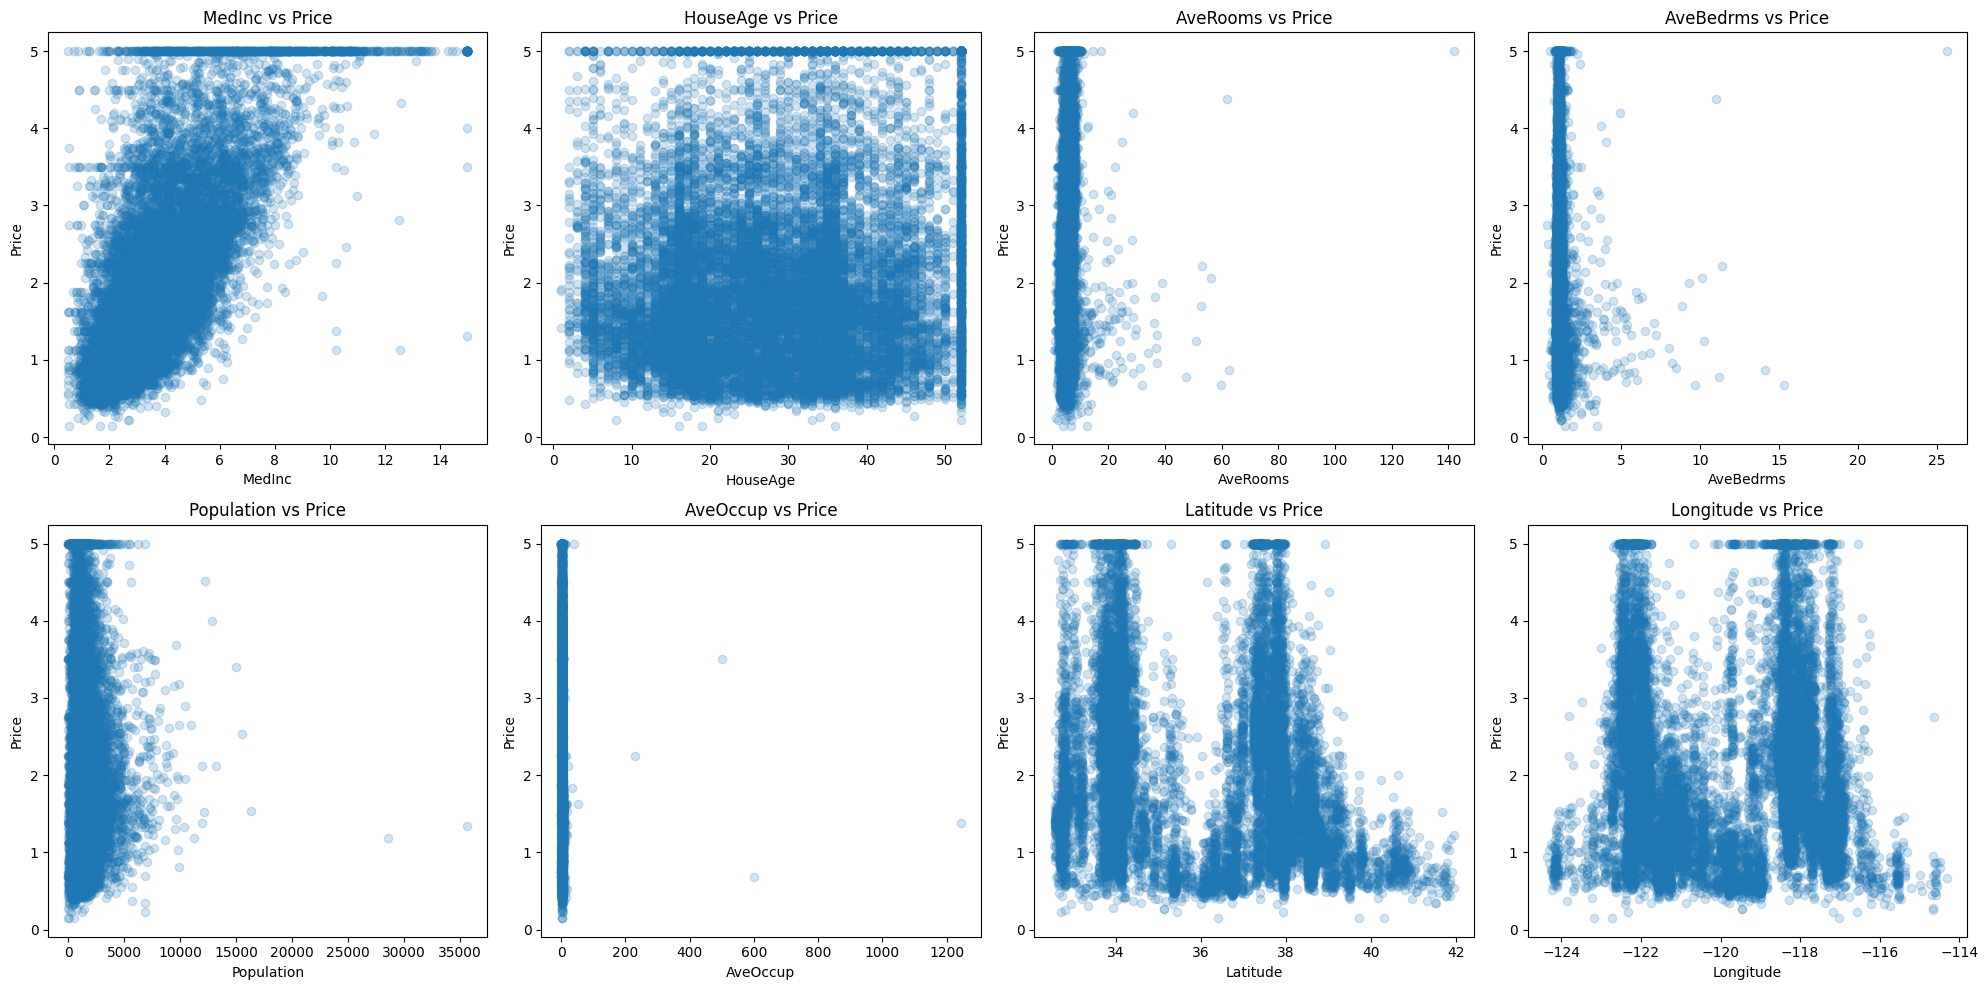

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    housing.data, housing.target, test_size=0.20, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # 2 rows, 4 cols = 8 plots
axes = axes.flatten()  # makes it easier to loop

for i, feature in enumerate(housing.feature_names):
    axes[i].scatter(X_train[feature], y_train, alpha=0.2)
    axes[i].set_title(f"{feature} vs Price")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Price")

plt.tight_layout()
plt.show()



In [55]:
model = linear_model.LinearRegression()
model.fit(X_train,y_train)
print("Weights:" , model.coef_)
print("Bias: " , model.intercept_)

Weights: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Bias:  -37.02327770606414


In [56]:
y_pred = model.predict(X_test)

print(f"Mean absolute error: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

Mean absolute error: 0.53
Mean squared error: 0.56
Coefficient of determination: 0.58


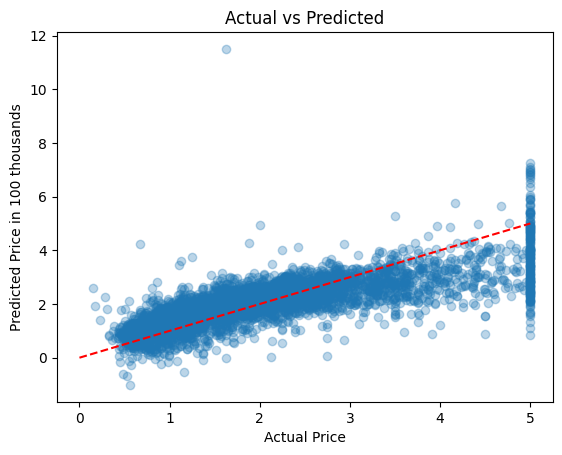

In [58]:
# Plot actual vs predicted
y_pred = model.predict(X_test)
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0, 5], [0, 5], 'r--')  # perfect prediction line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price in 100 thousands")
plt.title("Actual vs Predicted")
plt.show()